This notebook requires that the constraint and the numb_sites_region are run before

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
Constraint = pd.read_csv("Output_data/Constraint_perregion.csv")
numb_sites = pd.read_csv("Output_data/number_sites_perregion.csv")

In [3]:
Constraint = Constraint[Constraint["Sequence type"] != "IG"]
Constraint

,Sequence type,Constraint
0,cds,0.451172
1,introns,0.249704
2,3UTR,0.275495
3,5UTR,0.308225
4,intronsAR,0.138393
5,distalIG,0.039331
6,proximal5IG,0.115664
7,proximal3IG,0.134434


In [4]:
numb_sites = numb_sites[numb_sites["Sequence type"] != "IGAR"]
numb_sites

,Sequence type,Haploid sequence length
0,cds,5.820723e+07
1,introns,9.803886e+08
2,3UTR,9.429208e+06
3,5UTR,9.669105e+06
4,intronsAR,8.373507e+08
5,distalIG,3.914073e+08
6,proximal5IG,7.684621e+07
7,proximal3IG,7.698751e+07


In [5]:
mu = 1.34e-08

In [6]:
sum(numb_sites["Haploid sequence length"])

2440285890.8851132

Check visually that the two tables above have the same order of rows.

In [7]:
Udregion = mu*(Constraint["Constraint"] * 2 * (numb_sites["Haploid sequence length"]))
Udregion

0    0.703807
1    6.560831
2    0.069618
3    0.079871
4    3.105683
5    0.412573
6    0.238207
7    0.277372
dtype: float64

In [8]:
Ud = sum(Udregion)
Ud

11.447963507933567

Text(0, 0.5, '% of total Ud')

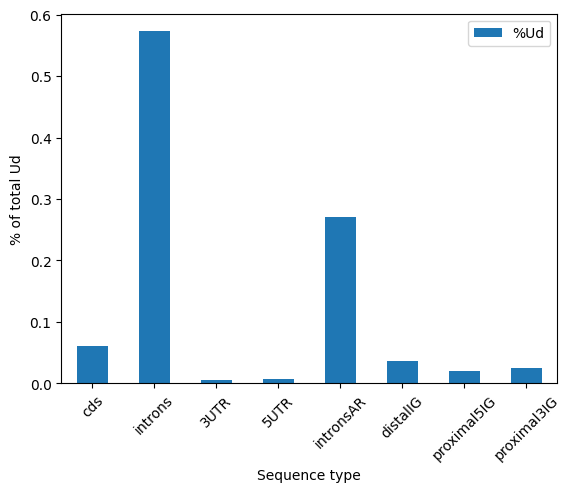

In [9]:
Uddata = pd.DataFrame({
    'Sequence type':  Constraint["Sequence type"],
    '%Ud': Udregion/Ud
})
Uddata.plot(
    x='Sequence type',
    kind = 'bar',
    rot=45)
plt.ylabel('% of total Ud')

In [10]:
Uddata

,Sequence type,%Ud
0,cds,0.061479
1,introns,0.573100
2,3UTR,0.006081
3,5UTR,0.006977
4,intronsAR,0.271287
5,distalIG,0.036039
6,proximal5IG,0.020808
7,proximal3IG,0.024229


In [12]:
0.573100 + 0.271287

0.844387